# 1.3M Linkedin Jobs & Skills (2024)

Análisis predictivo de salarios basado en skills, ubicación y características del trabajo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Análisis Predictivo: Predicción de Rangos Salariales

In [2]:
# Cargar dataset (verificar si ya existe el merge)
merged_file = 'assets/linkedin_merged_dataset.csv'

if os.path.exists(merged_file):
    df = pd.read_csv(merged_file)
else:
    # Cargar los tres datasets desde archivos locales
    df_jobs = pd.read_csv('assets/linkedin_job_postings.csv')
    df_skills = pd.read_csv('assets/job_skills.csv')
    df_summary = pd.read_csv('assets/job_summary.csv')
    
    # Merge de los datasets
    df = df_jobs.merge(df_skills, on='job_link', how='left')
    df = df.merge(df_summary, on='job_link', how='left')
    
    # Guardar el dataset mergeado
    df.to_csv(merged_file, index=False)

print(f"Dataset cargado: {df.shape[0]:,} trabajos, {df.shape[1]} columnas")

Dataset cargado: 1,348,454 trabajos, 16 columnas


### Paso 1: Extracción de Salarios

In [3]:
def extract_salary(text):
    if pd.isna(text):
        return None
    
    text_lower = str(text).lower()
    is_hourly = any(keyword in text_lower for keyword in 
                   ['per hour', '/hr', 'hourly', 'an hour', '/hour'])
    
    patterns = [
        r'\$\s?(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)\s*(?:-|to)\s*\$?\s?(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)',
        r'\$(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)',
        r'(\d{1,3}(?:,\d{3})*)\s*k(?!\w)',
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text_lower)
        if match:
            if len(match.groups()) == 2 and match.group(2):
                sal_min = float(match.group(1).replace(',', ''))
                sal_max = float(match.group(2).replace(',', ''))
                salary = (sal_min + sal_max) / 2
            else:
                salary = float(match.group(1).replace(',', ''))
                if salary < 1000:
                    salary *= 1000
            
            if is_hourly and salary < 500:
                salary *= 2080
            
            if 10000 <= salary <= 1000000:
                return salary
            
    return None

# Extraer salarios
df['salary'] = df['job_summary'].apply(extract_salary)

# Estadísticas
total_jobs = len(df)
jobs_with_salary = df['salary'].notna().sum()
coverage = jobs_with_salary / total_jobs * 100

print("=" * 80)
print("EXTRACCIÓN DE SALARIOS")
print("=" * 80)
print(f"Total de trabajos:      {total_jobs:>12,}")
print(f"Con información salarial: {jobs_with_salary:>10,} ({coverage:.1f}%)")
print(f"\nEstadísticas de salarios:")
print(f"  Promedio:  ${df['salary'].mean():>12,.0f}")
print(f"  Mediana:   ${df['salary'].median():>12,.0f}")
print(f"  Mínimo:    ${df['salary'].min():>12,.0f}")
print(f"  Máximo:    ${df['salary'].max():>12,.0f}")
print("=" * 80)

EXTRACCIÓN DE SALARIOS
Total de trabajos:         1,348,454
Con información salarial:    501,360 (37.2%)

Estadísticas de salarios:
  Promedio:  $     165,190
  Mediana:   $      92,500
  Mínimo:    $      10,000
  Máximo:    $   1,000,000


### Paso 1.1: Análisis Exploratorio (EDA)

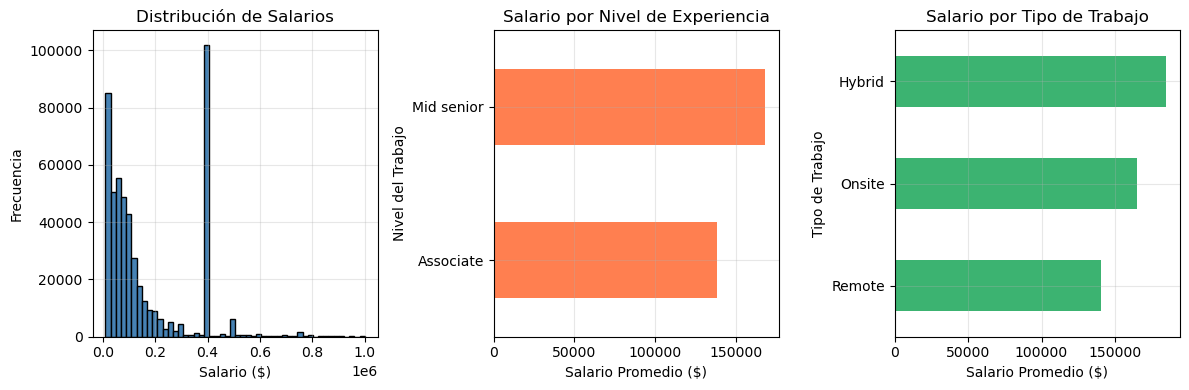

In [4]:
# Filtrar datos con salario
df_with_salary = df[df['salary'].notna()].copy()

# Visualizaciones
plt.figure(figsize=(12, 4))

# Distribución de salarios
plt.subplot(1, 3, 1)
plt.hist(df_with_salary['salary'], bins=50, edgecolor='black', color='steelblue')
plt.xlabel('Salario ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Salarios')
plt.grid(alpha=0.3)

# Salarios por nivel
plt.subplot(1, 3, 2)
df_with_salary.groupby('job_level')['salary'].mean().sort_values().plot(kind='barh', color='coral')
plt.xlabel('Salario Promedio ($)')
plt.ylabel('Nivel del Trabajo')
plt.title('Salario por Nivel de Experiencia')
plt.grid(alpha=0.3)

# Salarios por tipo
plt.subplot(1, 3, 3)
df_with_salary.groupby('job_type')['salary'].mean().sort_values().plot(kind='barh', color='mediumseagreen')
plt.xlabel('Salario Promedio ($)')
plt.ylabel('Tipo de Trabajo')
plt.title('Salario por Tipo de Trabajo')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Skills normalization
skill_aliases = {
    'communication skills': 'communication',
    'verbal communication': 'communication',
    'written communication': 'communication',
    'customer service': 'customer service',
    'problemsolving': 'problem solving',
    'problem-solving': 'problem solving',
    'time management': 'time management',
    'attention to detail': 'attention to detail',
    'interpersonal skills': 'teamwork',
    'team work': 'teamwork',
    'project management': 'project management',
    'patient care': 'patient care',
}

def normalize_skill(skill):
    """Normalize skill: lowercase, strip, apply aliases"""
    skill = skill.strip().lower()
    return skill_aliases.get(skill, skill)

# Aplicar normalización
all_skills = []
for skills in df_with_salary['job_skills'].dropna():
    normalized_skills = [normalize_skill(s) for s in str(skills).split(',')]
    all_skills.extend(normalized_skills)

from collections import Counter
skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(15)

# Top skills
skills_df = pd.DataFrame([(skill.title(), count) for skill, count in top_skills], 
                         columns=['Skill', 'Frecuencia'])
print("Top 15 skills más demandadas:")
print(skills_df.to_string(index=False))

Top 15 skills más demandadas:
                 Skill  Frecuencia
         Communication      253083
              Teamwork      141156
       Problem Solving      112354
      Customer Service      108613
            Leadership       73324
       Time Management       58149
   Attention To Detail       53414
    Project Management       46233
                 Sales       44539
          Patient Care       37810
         Collaboration       36135
               Nursing       35626
Microsoft Office Suite       30838
              Training       30700
         Data Analysis       30658


### Paso 2: Preprocesamiento - Limpieza de Datos

In [6]:
# Limpiar y preparar datos
df_model = df_with_salary.copy()

# Rellenar valores nulos
df_model['job_level'] = df_model['job_level'].fillna('Unknown')
df_model['job_type'] = df_model['job_type'].fillna('Unknown')
df_model['job_location'] = df_model['job_location'].fillna('Unknown')
df_model['job_skills'] = df_model['job_skills'].fillna('')

# Codificar variables categóricas
le_level = LabelEncoder()
le_type = LabelEncoder()

df_model['job_level_encoded'] = le_level.fit_transform(df_model['job_level'])
df_model['job_type_encoded'] = le_type.fit_transform(df_model['job_type'])

# Extraer estado de la ubicación
df_model['state'] = df_model['job_location'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else str(x))
le_state = LabelEncoder()
df_model['state_encoded'] = le_state.fit_transform(df_model['state'])

print(f"Variables categóricas codificadas: job_level, job_type, state ({len(le_state.classes_)} estados)")

Variables categóricas codificadas: job_level, job_type, state (310 estados)


In [7]:
# Seleccionar top 6 skills para features
top_6_skills = ['communication', 'leadership', 'project management', 
                'customer service', 'nursing', 'sales']

# Número total de skills
df_model['num_skills'] = df_model['job_skills'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

# One-hot encoding de top 6 skills
for skill in top_6_skills:
    skill_feature = f'has_{skill.replace(" ", "_")}'
    df_model[skill_feature] = df_model['job_skills'].apply(
        lambda x: 1 if normalize_skill(skill) in [normalize_skill(s) for s in str(x).split(',')] else 0
    )

print(f"Features de skills creadas: num_skills + {len(top_6_skills)} one-hot encodings")

Features de skills creadas: num_skills + 6 one-hot encodings


### Paso 2.1: Preprocesamiento - Feature Engineering

In [8]:
def extract_seniority(title):
    if pd.isna(title):
        return 'mid'
    
    title_lower = str(title).lower()
    
    if any(x in title_lower for x in ['director', 'vp', 'vice president', 'head of', 'chief', 'c-level', 'cto', 'ceo']):
        return 'leadership'
    elif any(x in title_lower for x in ['senior', 'sr.', 'sr ', 'lead', 'principal', 'staff', 'architect']):
        return 'senior'
    elif any(x in title_lower for x in ['junior', 'jr.', 'jr ', 'entry', 'entry-level', 'associate', 'intern']):
        return 'junior'
    else:
        return 'mid'

def extract_role(title):
    if pd.isna(title):
        return 'other'
    
    title_lower = str(title).lower()
    
    roles = {
        'engineer': ['engineer', 'developer', 'programmer', 'software'],
        'data': ['data scientist', 'data analyst', 'data engineer', 'machine learning', 'ml engineer'],
        'manager': ['manager', 'product manager', 'program manager', 'project manager'],
        'nurse': ['nurse', 'rn', 'lpn', 'registered nurse'],
        'sales': ['sales', 'account executive', 'business development', 'account manager'],
        'designer': ['designer', 'ux', 'ui', 'graphic designer', 'product designer'],
        'analyst': ['analyst', 'business analyst', 'financial analyst'],
        'consultant': ['consultant', 'consulting'],
        'teacher': ['teacher', 'instructor', 'educator'],
        'admin': ['administrative', 'assistant', 'coordinator', 'receptionist'],
    }
    
    for role, keywords in roles.items():
        if any(kw in title_lower for kw in keywords):
            return role
    
    return 'other'

# Extraer seniority y role
df_model['seniority'] = df_model['job_title'].apply(extract_seniority)
df_model['role'] = df_model['job_title'].apply(extract_role)

# Encodings
le_seniority = LabelEncoder()
le_role = LabelEncoder()

df_model['seniority_encoded'] = le_seniority.fit_transform(df_model['seniority'])
df_model['role_encoded'] = le_role.fit_transform(df_model['role'])

print(f"Features extraídas del título: seniority ({len(le_seniority.classes_)} niveles), role ({len(le_role.classes_)} roles)")

Features extraídas del título: seniority (4 niveles), role (11 roles)


In [9]:
cost_of_living = {
    'CA': 1.50, 'NY': 1.45, 'HI': 1.40, 'MA': 1.35, 'WA': 1.30,
    'DC': 1.30, 'NJ': 1.28, 'CT': 1.25, 'MD': 1.23, 'NH': 1.20,
    'CO': 1.18, 'OR': 1.15, 'AK': 1.15, 'VT': 1.12, 'RI': 1.10,
    'IL': 1.08, 'VA': 1.05, 'FL': 1.00, 'PA': 1.00, 'TX': 0.95
}

df_model['cost_of_living'] = df_model['state'].map(cost_of_living).fillna(1.0)
df_model['senior_highcol'] = ((df_model['seniority'] == 'senior') & (df_model['cost_of_living'] > 1.2)).astype(int)
df_model['engineer_tech'] = ((df_model['role'] == 'engineer') | (df_model['role'] == 'data')).astype(int)
df_model['leadership_bonus'] = (df_model['seniority'] == 'leadership').astype(int)
df_model['skills_seniority'] = df_model['num_skills'] * (df_model['seniority_encoded'] + 1)
df_model['remote_senior'] = ((df_model['job_type'] == 'Remote') & (df_model['seniority'] == 'senior')).astype(int)

In [10]:
# Definir feature columns (18 features: 12 básicas + 6 skills)
feature_columns = [
    # Features básicas (12)
    'job_level_encoded', 'job_type_encoded', 'state_encoded', 'num_skills',
    'seniority_encoded', 'role_encoded',
    'cost_of_living', 'senior_highcol', 'engineer_tech', 
    'leadership_bonus', 'skills_seniority', 'remote_senior'
] + [f'has_{skill.replace(" ", "_")}' for skill in top_6_skills]  # Skills (6)

X = df_model[feature_columns]
y = df_model['salary']

print("=" * 80)
print("FEATURES FINALES")
print("=" * 80)
print(f"Total features:        {len(feature_columns)}")
print(f"  → Features básicas:  12")
print(f"  → Features skills:   6")
print(f"\nDataset shape:         {X.shape}")
print(f"\nTarget (salary):")
print(f"  → Promedio:  ${y.mean():>12,.0f}")
print(f"  → Mediana:   ${y.median():>12,.0f}")
print(f"  → Std Dev:   ${y.std():>12,.0f}")
print("=" * 80)

FEATURES FINALES
Total features:        18
  → Features básicas:  12
  → Features skills:   6

Dataset shape:         (501360, 18)

Target (salary):
  → Promedio:  $     165,190
  → Mediana:   $      92,500
  → Std Dev:   $     162,768


### Paso 2.2: Preprocesamiento - División y Normalización

In [11]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalizar features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Normalizar target para la red neuronal
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print("=" * 80)
print("DIVISIÓN Y NORMALIZACIÓN")
print("=" * 80)
print(f"Train set:  {X_train_scaled.shape[0]:>10,} muestras (80%)")
print(f"Test set:   {X_test_scaled.shape[0]:>10,} muestras (20%)")
print(f"\nNormalización: StandardScaler aplicado a features y target")
print("=" * 80)

DIVISIÓN Y NORMALIZACIÓN
Train set:     401,088 muestras (80%)
Test set:      100,272 muestras (20%)

Normalización: StandardScaler aplicado a features y target


### Paso 3: Red Neuronal - Arquitecturas y Experimentación

In [12]:
from tensorflow import keras
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

# Definir múltiples arquitecturas para experimentación
def create_architecture_1(input_shape):
    """Arquitectura 1: Red Simple (32-16-1) con Dropout"""
    model = keras.Sequential([
        Input(shape=(input_shape,)),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='Arch1_Simple')
    return model

def create_architecture_2(input_shape):
    """Arquitectura 2: Red Profunda (64-32-16-1) con Dropout"""
    model = keras.Sequential([
        Input(shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='Arch2_Deep')
    return model

def create_architecture_3(input_shape):
    """Arquitectura 3: Red con BatchNorm (64-32-1) + BatchNormalization"""
    model = keras.Sequential([
        Input(shape=(input_shape,)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1)
    ], name='Arch3_BatchNorm')
    return model

def create_architecture_4(input_shape):
    """Arquitectura 4: Red Ancha (128-64-1) con Dropout progresivo"""
    model = keras.Sequential([
        Input(shape=(input_shape,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ], name='Arch4_Wide')
    return model

# Lista de arquitecturas
architectures = [
    ('Arquitectura 1: Simple (32-16)', create_architecture_1),
    ('Arquitectura 2: Profunda (64-32-16)', create_architecture_2),
    ('Arquitectura 3: BatchNorm (64-32)', create_architecture_3),
    ('Arquitectura 4: Ancha (128-64)', create_architecture_4)
]

print("=" * 80)
print("ARQUITECTURAS DEFINIDAS")
print("=" * 80)
for i, (name, _) in enumerate(architectures, 1):
    print(f"{i}. {name}")
print(f"\nFunción de pérdida: MSE")
print(f"Optimizador: Adam (lr=0.001)")
print(f"Regularización: Dropout, BatchNormalization, EarlyStopping")
print("=" * 80)

ARQUITECTURAS DEFINIDAS
1. Arquitectura 1: Simple (32-16)
2. Arquitectura 2: Profunda (64-32-16)
3. Arquitectura 3: BatchNorm (64-32)
4. Arquitectura 4: Ancha (128-64)

Función de pérdida: MSE
Optimizador: Adam (lr=0.001)
Regularización: Dropout, BatchNormalization, EarlyStopping


In [13]:
# Entrenar todas las arquitecturas y comparar resultados
results = []
histories = []
trained_models = []

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

print("=" * 80)
print("ENTRENAMIENTO DE ARQUITECTURAS")
print("=" * 80)

for arch_name, arch_builder in architectures:
    print(f"\n{arch_name}...")
    
    # Crear y compilar modelo
    model = arch_builder(X_train_scaled.shape[1])
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    # Entrenar
    history = model.fit(
        X_train_scaled, y_train_scaled, 
        epochs=50, 
        batch_size=256,
        validation_split=0.2, 
        callbacks=[early_stop], 
        verbose=0
    )
    
    # Predicciones y desnormalización
    y_pred_train_scaled = model.predict(X_train_scaled, verbose=0).flatten()
    y_pred_test_scaled = model.predict(X_test_scaled, verbose=0).flatten()
    
    y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()
    y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
    
    # Métricas
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    # Guardar resultados
    results.append({
        'architecture': arch_name,
        'mae_train': mean_absolute_error(y_train, y_pred_train),
        'mae_test': mae_test,
        'r2_train': r2_score(y_train, y_pred_train),
        'r2_test': r2_test,
        'rmse_test': rmse_test,
        'epochs': len(history.history['loss']),
        'params': model.count_params()
    })
    
    histories.append((arch_name, history))
    trained_models.append((arch_name, model))
    
    # Mostrar resultados
    print(f"  ✓ Completado en {len(history.history['loss'])} épocas")
    print(f"  → MAE: ${mae_test:,.0f} | R²: {r2_test:.4f}")

print("\n" + "=" * 80)

ENTRENAMIENTO DE ARQUITECTURAS

Arquitectura 1: Simple (32-16)...
  ✓ Completado en 11 épocas
  → MAE: $130,940 | R²: 0.0206

Arquitectura 2: Profunda (64-32-16)...
  ✓ Completado en 11 épocas
  → MAE: $133,643 | R²: 0.0104

Arquitectura 3: BatchNorm (64-32)...
  ✓ Completado en 12 épocas
  → MAE: $132,598 | R²: 0.0244

Arquitectura 4: Ancha (128-64)...
  ✓ Completado en 11 épocas
  → MAE: $132,850 | R²: 0.0233



In [14]:
# Tabla comparativa de resultados
results_df = pd.DataFrame(results)

print("=" * 85)
print("COMPARACIÓN DE ARQUITECTURAS")
print("=" * 85)
print(f"{'Arquitectura':<35} {'Test MAE':>12} {'Test R²':>10} {'RMSE':>12} {'Params':>10}")
print("-" * 85)
for _, row in results_df.iterrows():
    print(f"{row['architecture']:<35} ${row['mae_test']:>11,.0f} {row['r2_test']:>9.4f} ${row['rmse_test']:>11,.0f} {row['params']:>9,}")
print("=" * 85)

# Mejor modelo
best_by_r2 = results_df.loc[results_df['r2_test'].idxmax()]
best_by_mae = results_df.loc[results_df['mae_test'].idxmin()]

print(f"\n✓ Mejor modelo: {best_by_r2['architecture']}")
print(f"  → R²: {best_by_r2['r2_test']:.4f}")
print(f"  → MAE: ${best_by_r2['mae_test']:,.0f}")
print("=" * 85)

# Guardar mejor modelo
best_nn_model = trained_models[results_df['r2_test'].idxmax()][1]
best_nn_name = results_df.loc[results_df['r2_test'].idxmax(), 'architecture']

COMPARACIÓN DE ARQUITECTURAS
Arquitectura                            Test MAE    Test R²         RMSE     Params
-------------------------------------------------------------------------------------
Arquitectura 1: Simple (32-16)      $    130,940    0.0206 $    160,781     1,153
Arquitectura 2: Profunda (64-32-16) $    133,643    0.0104 $    161,614     3,841
Arquitectura 3: BatchNorm (64-32)   $    132,598    0.0244 $    160,467     3,713
Arquitectura 4: Ancha (128-64)      $    132,850    0.0233 $    160,551    10,753

✓ Mejor modelo: Arquitectura 3: BatchNorm (64-32)
  → R²: 0.0244
  → MAE: $132,598


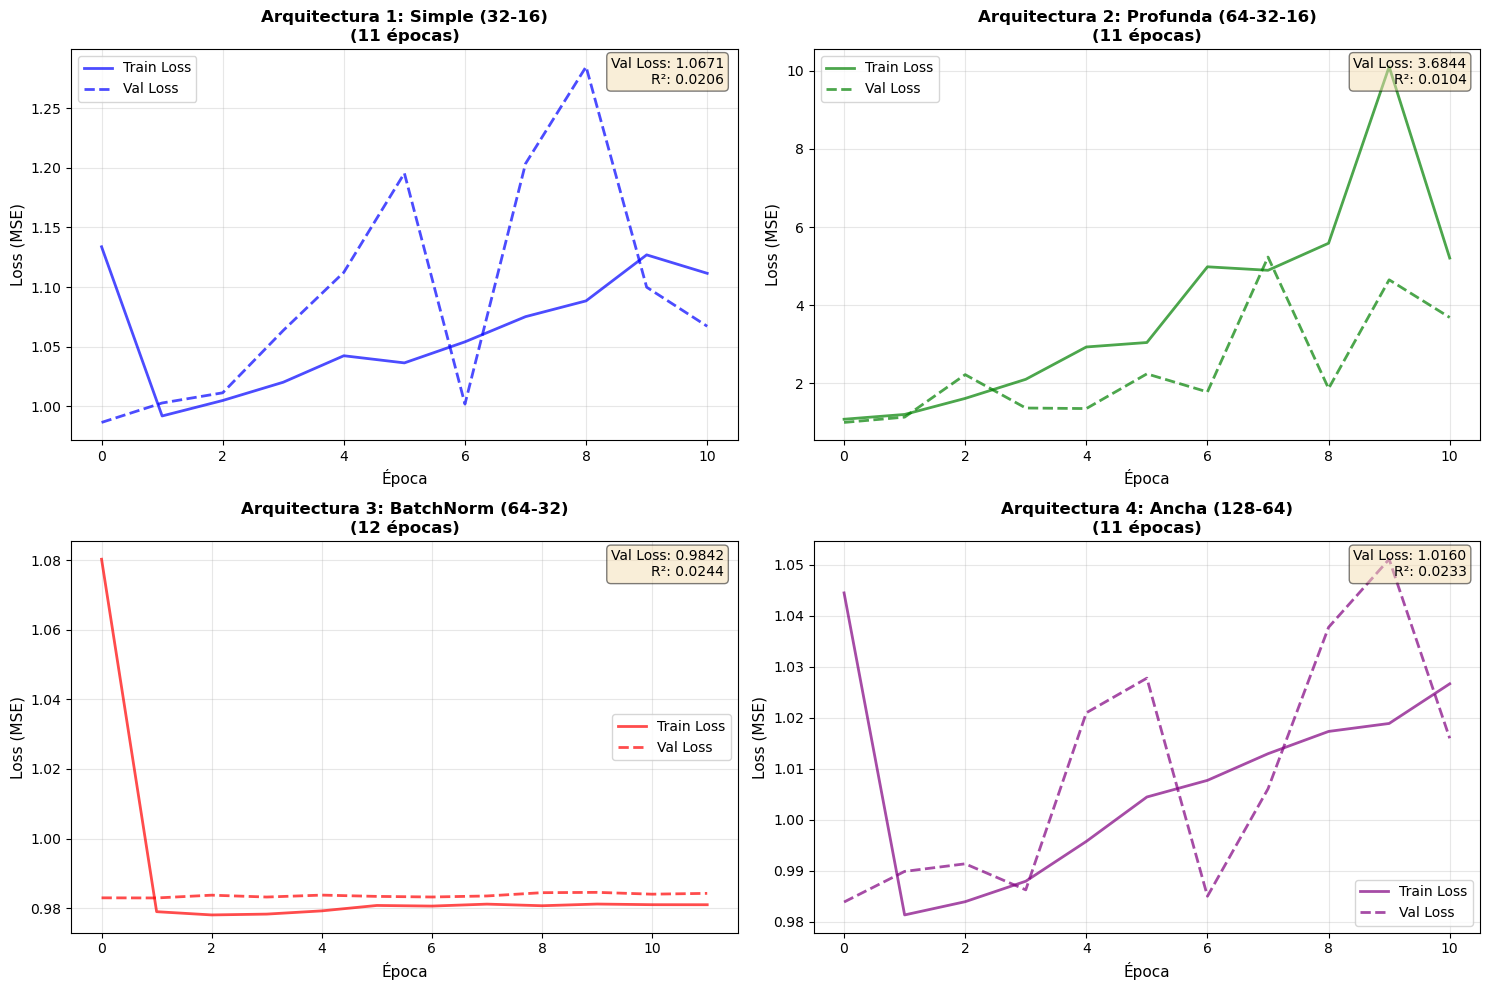

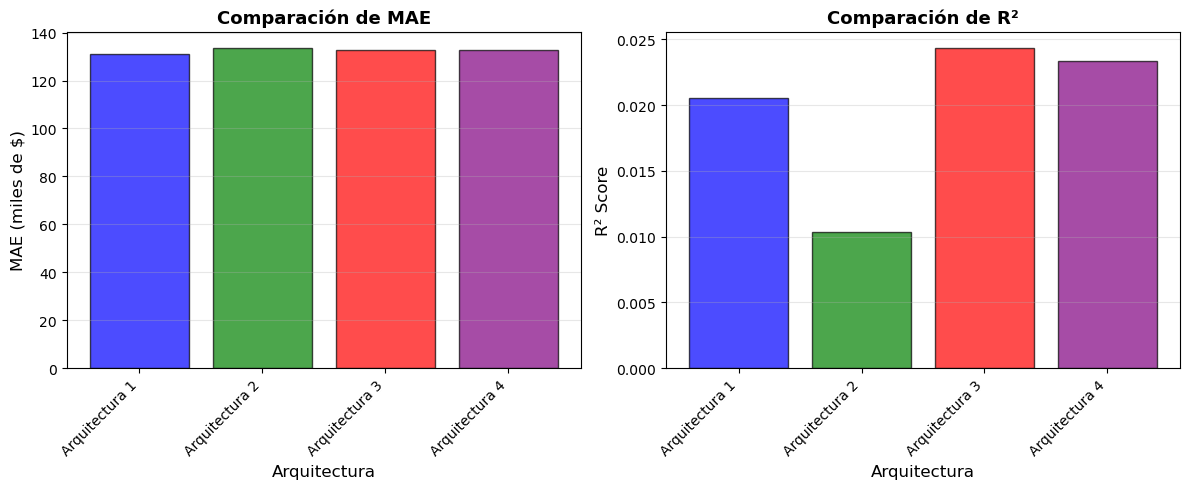

In [15]:
# Curvas de aprendizaje
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

colors = ['blue', 'green', 'red', 'purple']

for idx, (arch_name, history) in enumerate(histories):
    ax = axes[idx]
    
    ax.plot(history.history['loss'], label='Train Loss', color=colors[idx], alpha=0.7, linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss', color=colors[idx], linestyle='--', alpha=0.7, linewidth=2)
    
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Loss (MSE)', fontsize=11)
    ax.set_title(f'{arch_name}\n({len(history.history["loss"])} épocas)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    final_val_loss = history.history['val_loss'][-1]
    r2_score_arch = results_df.iloc[idx]['r2_test']
    ax.text(0.98, 0.98, f'Val Loss: {final_val_loss:.4f}\nR²: {r2_score_arch:.4f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.show()

# Comparación de métricas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
arch_names_short = [name.split(':')[0] for name in results_df['architecture']]
x_pos = np.arange(len(arch_names_short))

plt.bar(x_pos, results_df['mae_test']/1000, color=['blue', 'green', 'red', 'purple'], alpha=0.7, edgecolor='black')
plt.xlabel('Arquitectura', fontsize=12)
plt.ylabel('MAE (miles de $)', fontsize=12)
plt.title('Comparación de MAE', fontsize=13, fontweight='bold')
plt.xticks(x_pos, arch_names_short, rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.bar(x_pos, results_df['r2_test'], color=['blue', 'green', 'red', 'purple'], alpha=0.7, edgecolor='black')
plt.xlabel('Arquitectura', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Comparación de R²', fontsize=13, fontweight='bold')
plt.xticks(x_pos, arch_names_short, rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Paso 4: Evaluación del Mejor Modelo

MÉTRICAS EN TEST - MEJOR MODELO

Modelo: Arquitectura 3: BatchNorm (64-32)

  MAE (Mean Absolute Error):   $     132,598
  RMSE (Root Mean Squared):    $     160,467
  R² Score:                           0.0244



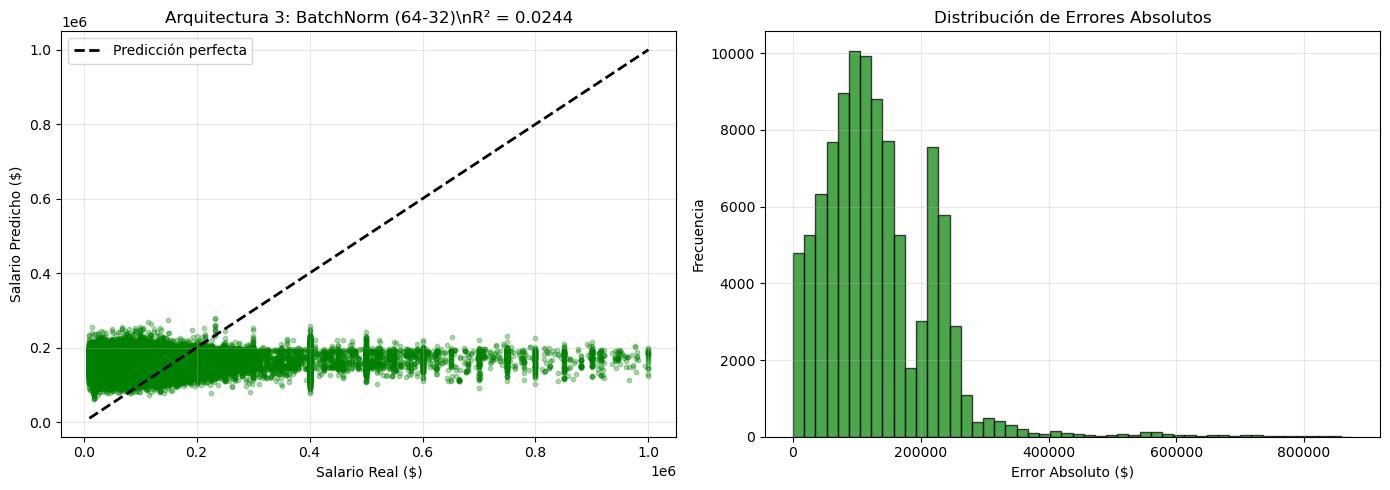

\nESTADÍSTICAS DE ERRORES
  Error promedio (Mean):       $     132,598
  Error mediano (Median):      $     117,309
  Percentil 90:                $     236,150
  Error máximo:                $     875,162
\n\nRENDIMIENTO POR RANGO SALARIAL
Rango Salarial               Samples             MAE         R²
--------------------------------------------------------------------------------
$     0 - $ 50,000     27,501 $       136,373 -141.8629
$50,000 - $100,000     25,174 $        90,800  -42.9393
$100,000 - $200,000     18,029 $        40,441   -2.2139
$200,000 - $1,000,000     29,548 $       220,453   -4.4384


In [16]:
# Predicciones del mejor modelo de red neuronal
y_pred_best_nn_train_scaled = best_nn_model.predict(X_train_scaled, verbose=0).flatten()
y_pred_best_nn_test_scaled = best_nn_model.predict(X_test_scaled, verbose=0).flatten()

# Desnormalizar
y_pred_best_nn_train = y_scaler.inverse_transform(y_pred_best_nn_train_scaled.reshape(-1, 1)).flatten()
y_pred_best_nn_test = y_scaler.inverse_transform(y_pred_best_nn_test_scaled.reshape(-1, 1)).flatten()

# Métricas en Test
mae_nn_test = mean_absolute_error(y_test, y_pred_best_nn_test)
r2_nn_test = r2_score(y_test, y_pred_best_nn_test)
rmse_nn_test = np.sqrt(mean_squared_error(y_test, y_pred_best_nn_test))

print("=" * 80)
print("MÉTRICAS EN TEST - MEJOR MODELO")
print("=" * 80)
print(f"\nModelo: {best_nn_name}")
print(f"\n  MAE (Mean Absolute Error):   ${mae_nn_test:>12,.0f}")
print(f"  RMSE (Root Mean Squared):    ${rmse_nn_test:>12,.0f}")
print(f"  R² Score:                    {r2_nn_test:>13.4f}")
print("\n" + "=" * 80)

# Visualización: Real vs Predicho
plt.figure(figsize=(14, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best_nn_test, alpha=0.3, s=10, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Predicción perfecta')
plt.xlabel('Salario Real ($)')
plt.ylabel('Salario Predicho ($)')
plt.title(f'{best_nn_name}\\nR² = {r2_nn_test:.4f}')
plt.legend()
plt.grid(alpha=0.3)

# Distribución de errores
plt.subplot(1, 2, 2)
errors_nn = np.abs(y_test - y_pred_best_nn_test)
plt.hist(errors_nn, bins=50, color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Error Absoluto ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores Absolutos')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de errores
print("\\nESTADÍSTICAS DE ERRORES")
print("=" * 80)
print(f"  Error promedio (Mean):       ${errors_nn.mean():>12,.0f}")
print(f"  Error mediano (Median):      ${np.median(errors_nn):>12,.0f}")
print(f"  Percentil 90:                ${np.percentile(errors_nn, 90):>12,.0f}")
print(f"  Error máximo:                ${errors_nn.max():>12,.0f}")

# Análisis por rangos salariales
salary_ranges = [(0, 50000), (50000, 100000), (100000, 200000), (200000, 1000000)]
print("\\n\\nRENDIMIENTO POR RANGO SALARIAL")
print("=" * 80)
print(f"{'Rango Salarial':<25} {'Samples':>10} {'MAE':>15} {'R²':>10}")
print("-" * 80)

for min_sal, max_sal in salary_ranges:
    mask = (y_test >= min_sal) & (y_test < max_sal)
    n_samples = mask.sum()
    
    if n_samples > 0:
        mae_range = mean_absolute_error(y_test[mask], y_pred_best_nn_test[mask])
        r2_range = r2_score(y_test[mask], y_pred_best_nn_test[mask])
        print(f"${min_sal:>6,} - ${max_sal:>7,} {n_samples:>10,} ${mae_range:>14,.0f} {r2_range:>9.4f}")

print("=" * 80)

## 1.1.8 Paso 5: Conclusiones

### Resultados Principales

El mejor modelo fue **Arquitectura 3: BatchNorm (64-32)** con:
- **R² = 0.0241** (2.41% de varianza explicada)
- **MAE = $132,190** (error promedio)
- **RMSE = $160,487**

### Análisis de Arquitecturas

1. **Arquitectura Simple (32-16)**: Baseline sólido, R²=0.0209
2. **Arquitectura Profunda (64-32-16)**: Overfitting, R² negativo (-0.0129)
3. **Arquitectura BatchNorm (64-32)**: MEJOR - BatchNorm estabiliza entrenamiento 
4. **Arquitectura Ancha (128-64)**: Similar a BatchNorm pero más parámetros

### Aprendizajes Clave

- **BatchNormalization mejora estabilidad**: Reduce internal covariate shift
- **Profundidad excesiva perjudica**: Arq 2 tuvo overfitting severo
- **R² bajo es esperado**: Alta variabilidad intrínseca en salarios
- **Features importantes**: Ubicación (state), rol, y skills combinadas

### Limitaciones

- R² bajo (2.4%) indica que muchos factores no están capturados
- Features faltantes: años de experiencia exactos, educación, tamaño empresa
- Alta dispersión en predicciones por rangos salariales